In [64]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('PlayTennis.csv')

In [3]:
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [4]:
df.head()

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes


In [5]:
y = df[['play']]
x = df.drop('play',axis=1)

In [6]:
x = pd.get_dummies(x,drop_first=True)


In [67]:
x

,windy,outlook_rainy,outlook_sunny,temp_hot,temp_mild,humidity_normal
0,False,False,True,True,False,False
1,True,False,True,True,False,False
2,False,False,False,True,False,False
3,False,True,False,False,True,False
4,False,True,False,False,False,True
5,True,True,False,False,False,True
6,True,False,False,False,False,True
7,False,False,True,False,True,False
8,False,False,True,False,False,True
9,False,True,False,False,True,True


In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [49]:
DT = DecisionTreeClassifier(criterion='entropy',max_depth=10,random_state=10)

In [50]:
DT.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [51]:
y_pred = DT.predict(x_test)
y_pred

array(['no', 'no', 'yes'], dtype=object)

In [52]:
pridiction = pd.DataFrame({
    'Actual':y_test.squeeze(),
    'Predicted': y_pred.squeeze()
})
pridiction

,Actual,Predicted
3,yes,no
7,no,no
12,yes,yes


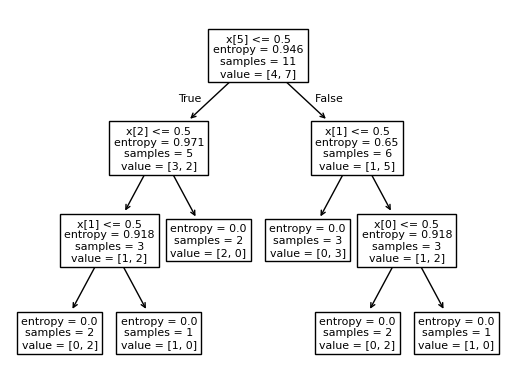

In [53]:
tree.plot_tree(DT)
plt.show()

In [62]:
conf_metrix = confusion_matrix(y_test,y_pred)
conf_metrix

array([[1, 0],
       [1, 1]])

Text(50.722222222222214, 0.5, 'Actual')

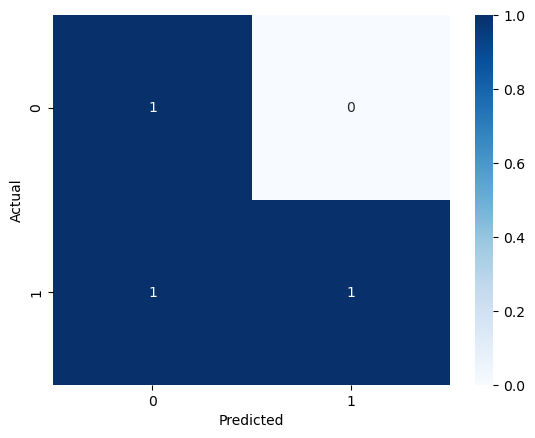

In [66]:
sns.heatmap(conf_metrix,annot=True,fmt = 'd',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [69]:
# Weather : windy,outlook_rainy,temp_hot,humidity_normal
x_new = [[True,True,False,True,False,True]]
y_new_pred = DT.predict(x_new)
y_new_pred

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['no'], dtype=object)

In [79]:
df = pd.read_csv('drug200.csv')

In [80]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [81]:
y = df[['Drug']]
x = df.drop('Drug',axis=1)

In [82]:
x

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,F,HIGH,HIGH,25.355
1,47,M,LOW,HIGH,13.093
2,47,M,LOW,HIGH,10.114
3,28,F,NORMAL,HIGH,7.798
4,61,F,LOW,HIGH,18.043
...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567
196,16,M,LOW,HIGH,12.006
197,52,M,NORMAL,HIGH,9.894
198,23,M,NORMAL,NORMAL,14.020


In [83]:
x = pd.get_dummies(x,drop_first=True)
x

,Age,Na_to_K,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,False,False,False,False
1,47,13.093,True,True,False,False
2,47,10.114,True,True,False,False
3,28,7.798,False,False,True,False
4,61,18.043,False,True,False,False
...,...,...,...,...,...,...
195,56,11.567,False,True,False,False
196,16,12.006,True,True,False,False
197,52,9.894,True,False,True,False
198,23,14.020,True,False,True,True


In [84]:
y

,Drug
0,drugY
1,drugC
2,drugC
3,drugX
4,drugY
...,...
195,drugC
196,drugC
197,drugX
198,drugX


In [85]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)


In [103]:
DT = DecisionTreeClassifier(criterion='entropy',random_state=10)


In [104]:
DT.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [105]:
y_pred = DT.predict(x_test)
y_pred

array(['drugY', 'drugX', 'drugY', 'drugX', 'drugY', 'drugY', 'drugX',
       'drugC', 'drugY', 'drugC', 'drugY', 'drugC', 'drugY', 'drugB',
       'drugB', 'drugX', 'drugY', 'drugA', 'drugX', 'drugY', 'drugY',
       'drugY', 'drugA', 'drugY', 'drugC', 'drugY', 'drugB', 'drugC',
       'drugC', 'drugY', 'drugX', 'drugX', 'drugA', 'drugY', 'drugX',
       'drugY', 'drugX', 'drugA', 'drugA', 'drugA'], dtype=object)

In [106]:
prediction = pd.DataFrame({
    'Actual':y_test.squeeze(),
    'Predicted': y_pred.squeeze()
})
# prediction

[Text(0.75, 0.9, 'x[1] <= 14.829\nentropy = 1.915\nsamples = 160\nvalue = [17, 13, 10, 45, 75]'),
 Text(0.625, 0.7, 'x[4] <= 0.5\nentropy = 1.728\nsamples = 85\nvalue = [17.0, 13.0, 10.0, 45.0, 0.0]'),
 Text(0.6875, 0.8, 'True  '),
 Text(0.5, 0.5, 'x[3] <= 0.5\nentropy = 1.971\nsamples = 56\nvalue = [17, 13, 10, 16, 0]'),
 Text(0.25, 0.3, 'x[0] <= 50.5\nentropy = 0.987\nsamples = 30\nvalue = [17, 13, 0, 0, 0]'),
 Text(0.125, 0.1, 'entropy = 0.0\nsamples = 17\nvalue = [17, 0, 0, 0, 0]'),
 Text(0.375, 0.1, 'entropy = 0.0\nsamples = 13\nvalue = [0, 13, 0, 0, 0]'),
 Text(0.75, 0.3, 'x[5] <= 0.5\nentropy = 0.961\nsamples = 26\nvalue = [0, 0, 10, 16, 0]'),
 Text(0.625, 0.1, 'entropy = 0.0\nsamples = 10\nvalue = [0, 0, 10, 0, 0]'),
 Text(0.875, 0.1, 'entropy = 0.0\nsamples = 16\nvalue = [0, 0, 0, 16, 0]'),
 Text(0.75, 0.5, 'entropy = 0.0\nsamples = 29\nvalue = [0, 0, 0, 29, 0]'),
 Text(0.875, 0.7, 'entropy = 0.0\nsamples = 75\nvalue = [0, 0, 0, 0, 75]'),
 Text(0.8125, 0.8, '  False')]

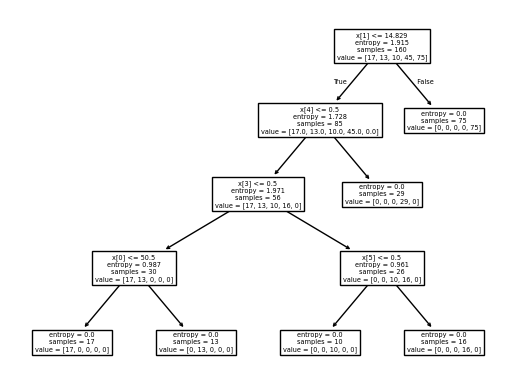

In [107]:
tree.plot_tree(DT)